# Temporal Evolution of the Disaster Footprint

## Executive summary
Track the disaster footprint area across acquisition dates and export a compact time series for situation reporting.

## Prerequisites
Optional dated GeoJSON files can go in `data/cems/temporal/`. If that folder is empty, this notebook measures the local Copernicus file for the `activation_id` in `config/params.yaml` (one snapshot per layer). That is the usual case for a single grading product such as EMSR884.

## Parameters
The input directory and output locations are explicit so the temporal run can be repeated for another activation.

In [1]:
from pathlib import Path
import sys
import geopandas as gpd
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.copernicus_loader import copernicus_file, load_params

params = load_params(PROJECT_ROOT)
ACTIVATION_ID = params['activation_id']
INPUT_DIR = PROJECT_ROOT / 'data' / 'cems' / 'temporal'
DATE_COLUMN = 'date'
OUTPUT_CSV = PROJECT_ROOT / 'data' / 'temporal_impact.csv'
OUTPUT_PNG = PROJECT_ROOT / 'data' / 'temporal_impact.png'
print({'activation_id': ACTIVATION_ID, 'temporal_dir': str(INPUT_DIR)})

{'activation_id': 'EMSR884', 'temporal_dir': 'c:\\Users\\loai\\Dropbox\\20251211-Action\\IFRC Project\\usecase2\\notebooks\\montandon_impact_estimation\\data\\cems\\temporal'}


## Build dated footprint measurements
Each footprint is reprojected to a local metric CRS before area is calculated. Filename dates are used as a fallback when the layer has no date field.

In [2]:
import re
from src.copernicus_loader import concat_layers, filter_impact, load_copernicus_layers
from src.spatial_analysis import choose_analysis_crs

TEMPORAL_COLUMNS = ['date', 'impact_area_km2', 'feature_count', 'source']


def snapshot_date(footprint, label):
    if DATE_COLUMN in footprint.columns:
        parsed = pd.to_datetime(footprint[DATE_COLUMN].iloc[0], errors='coerce')
        if pd.notna(parsed):
            return parsed
    match = re.search(r'(20\d{6})', str(label))
    if match:
        return pd.to_datetime(match.group(1), format='%Y%m%d')
    return pd.NaT


def measure_footprint(footprint, source_label):
    if footprint.empty or footprint.crs is None:
        return None
    analysis_crs = choose_analysis_crs(footprint)
    return {
        'date': snapshot_date(footprint, source_label),
        'impact_area_km2': footprint.to_crs(analysis_crs).geometry.area.sum() / 1_000_000,
        'feature_count': len(footprint),
        'source': source_label,
    }


records = []
INPUT_DIR.mkdir(parents=True, exist_ok=True)
for path in sorted(INPUT_DIR.glob('*.geojson')):
    footprint = gpd.read_file(path)
    record = measure_footprint(footprint, path.name)
    if record:
        records.append(record)

if not records:
    copernicus_path = copernicus_file(PROJECT_ROOT, ACTIVATION_ID)
    layers = load_copernicus_layers(copernicus_path)
    for name, layer in layers.items():
        record = measure_footprint(filter_impact(layer, params), f'{copernicus_path.name}:{name}')
        if record:
            records.append(record)

temporal = pd.DataFrame(records, columns=TEMPORAL_COLUMNS)
if not temporal.empty:
    temporal = temporal.sort_values('date', na_position='last')
display(temporal)

,date,impact_area_km2,feature_count,source
0,2026-07-01,9.498091,69431,data.gpkg:EMSR884_damage_confidence_20260701_v1


## Plot and export the evolution
The helper produces a consistent report-ready chart and the CSV preserves source filenames for auditability.

{'csv': 'c:\\Users\\loai\\Dropbox\\20251211-Action\\IFRC Project\\usecase2\\notebooks\\montandon_impact_estimation\\data\\temporal_impact.csv', 'png': 'c:\\Users\\loai\\Dropbox\\20251211-Action\\IFRC Project\\usecase2\\notebooks\\montandon_impact_estimation\\data\\temporal_impact.png', 'snapshots': 1}


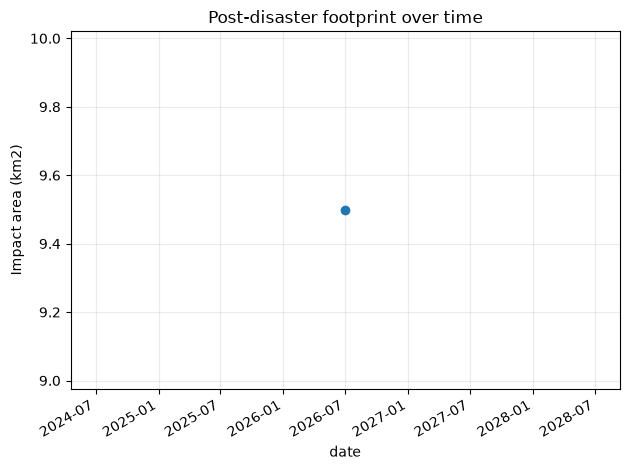

In [3]:
from src.visualization import plot_temporal_evolution

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
if temporal.empty:
    print(f'No temporal snapshots found in {INPUT_DIR} or the local Copernicus file')
else:
    temporal.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
    if temporal['date'].notna().sum() >= 1:
        axis = plot_temporal_evolution(temporal.dropna(subset=['date']))
        axis.figure.tight_layout()
        axis.figure.savefig(OUTPUT_PNG, dpi=150)
        print({'csv': str(OUTPUT_CSV), 'png': str(OUTPUT_PNG), 'snapshots': len(temporal)})
    else:
        print({'csv': str(OUTPUT_CSV), 'snapshots': len(temporal), 'note': 'no parseable dates to plot'})